# Analysis of monolayer dynamics

In this script we analyse and compare the dynamics in experimental and simulated monolayers.
We use cage diffusion and mean square displacement to characterise the dynamics.

In [1]:
import sys
# import scipy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import curve_fit

sys.path.append("scripts/utils/")
import config_functions   as config
import vm_output_handling as vm_output

# from plot_utils import hist_to_curve
from SegmentedCells import SegmentedCells
from dynamics_analysis import *

data_path = "../../../../hdd_data/silja/VertexModel/"
savefig   = False

In [2]:
def average_lists_with_lenghts(x_lists, y_lists):
    x_max = min([max(x)      for x in x_lists])
    dx    = min([x[1] - x[0] for x in x_lists])
    x_common = np.arange(0, x_max, dx)
    interp = []

    for x_k, y_k in zip(x_lists, y_lists):
        interp_k = np.interp(x_common, x_k, y_k)
        interp.append(interp_k)

    array = np.stack(interp)
    mean   = array.mean(axis=0)
    sem    = array.std(axis=0) / np.sqrt(len(array))

    return x_common, mean

## Loading data from simulations and experiments

In [3]:
# Width of cell number density bins used to group experimental data
bin_size = 200

# Bin centers for grouping experimental data by cell number density
density_bins = np.arange(1400, 3100+bin_size, bin_size)

# Array of frames per hour for each dataset
frames_per_hour = np.concatenate([np.repeat(12, 12), np.repeat(4, 2)])
cmap_exp        = mpl.colormaps["Blues"](np.linspace(0.3, 1, len(frames_per_hour)))


# List of experimental dataset identifiers
exp_dataset_ids = [
    "MDCK_20240301_B1-4",
    #"MDCK_20240301_B2-2",
    "MDCK_20240301_B2-6",
    "MDCK_20240317_B1-1",
    "MDCK_20240319_A1-9",
    "MDCK_20240319_A1-13",
    #"MDCK_20240319_A1-16",
    "MDCK_20240319_A1-18",
    "MDCK_20240319_B1-11",
    "MDCK_20240516_A2-1",
    "MDCK_20240516_A2-7",
    "MDCK_20240516_B1-9",
    "MDCK_20240516_B1-13",
    "MDCK_20240516_B1-22",
    "MDCK_20250904_B1-1",
    "MDCK_20250210_A2-1",
    ]



# Load experimental cell segmentation data
density_masks   = []
cell_properties = []

# Load segmented cell properties for each experimental dataset
for dataset in exp_dataset_ids:
    cell_prop = SegmentedCells(f"{data_path}/exp/raw/{dataset}_cells.p")
    cell_properties.append(cell_prop)


# Group experiments into density bins
for density in density_bins:
    tmp_bin_mask = []

    for cell_prop in cell_properties:

        # Select cells whose local number density falls within the bin centered at `density`
        mask = (cell_prop.density > density - bin_size / 2) & (cell_prop.density < density + bin_size / 2)
        tmp_bin_mask.append(mask)

    density_masks.append(tmp_bin_mask)

State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240319_B1-11_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240516_A2-1_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240516_A2-7_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel//exp/raw/MDCK_20240516_B1-9_cells.p.
State loaded from ../../../../hdd_data/silja/VertexModel/

In [4]:
# Load simulation data

# Simulation parameter values for the datasets to load
dates   = [20260810]
gammas  = [18]
lambdas = [100]
v0s     = [100]
taus    = [175]
etas    = [50]
N_cells = [36, 42, 48, 54]

densities = np.array(0.5 * (np.array(N_cells) / 0.3)**2 * 1 / np.sqrt(27))


# Define comparison label and plot colors based on N
variable_sim = densities
cmap_sim     = mpl.colormaps["Reds"](np.linspace(0.4, 0.9, len(variable_sim)))

# Full file paths to simulation datasets for the chosen parameter combinations. Construct dataset file paths using the simulation naming convention and selected parameters
sim_paths = [f"{data_path}sim/raw/nodivision_{dates[0]}_N{N_cells[i]}_L600_gamma{gammas[0]}_lambda{lambdas[0]}_v0{v0s[0]}_taup{taus[0]}_eta{etas[0]}.p" for i in range(len(variable_sim))]

vm_datasets = []

# Loop over simulation datasets
for filepath in sim_paths:

    # Load simulation configuration for this dataset
    config_path = f"configs/{Path(filepath).stem}.json"
    config_file = config.load(config_path)

    # Compute physical time between stored frames
    dt = config_file["simulation"]["dt"]
    T  = config_file["simulation"]["period"]
    df = T * dt

    # Load simulation frames as vm objects
    frames, initial_frames = vm_output.load(filepath, df=df)
    vm_datasets.append(frames)

## Doing analysis

In [5]:
# Experimental data
# Time lag for cage statistics (in hours)
lag_time = 1
neighbour_search_factor = 2.7


# Aggregate cage statistics and MSD across density bins
cage_distances_exp      = []
N_neighbours_exp        = []
fraction_neighbours_exp = []
lag_exp                 = []
msd_exp                 = []

# Loop over cell number density bins. For each density bin, compute cage statistics and MSD for all datasets using the corresponding masks
bin_index = 0
for density in density_bins:

    cage_distances_tmp      = []
    N_neighbours_tmp        = []
    fraction_neighbours_tmp = []
    lag_tmp                 = []
    msd_tmp                 = []

    # Compute dynamical metrics for each dataset in this density bin
    for cell_prop, mask, t in zip(cell_properties, 
                                  density_masks[bin_index], 
                                  frames_per_hour * lag_time):

        # Skip datasets / bins that do not contain sufficient frames or valid data for this lag
        try:

            # Extract cell positions
            pos    = np.array([cell_prop.x[mask].T, cell_prop.y[mask].T]).T
            pos_t0 = pos[0]
            pos_t  = pos[t]

            # Compute mean square displacement
            lag, msd = compute_msd(pos, mask_empty=True)
            lag_tmp.append(lag / t)
            msd_tmp.append(msd)

            # Remove cells that are absent or dead at t or not yet present at t0
            pos_t0[pos_t == 0] = 0
            pos_t[pos_t0 == 0] = 0

            # Compute mean cell radius in this bin. Used to set the neighbour search range
            r_cell       = np.ma.mean(np.sqrt(cell_prop.A / np.pi))
            search_range = r_cell * neighbour_search_factor

            # Get list of neighbors of each cell at t0 and t
            neighbours_t0 = build_neighbours_distance(pos_t0, search_range)
            neighbours_t  = build_neighbours_distance(pos_t,  search_range)
            N_neighbours_tmp.append([len(n) for n in neighbours_t0])

            # Compute cage displacement for each cell based on neighbor motion
            cage_displacement = compute_cage_displacement(pos_t0, pos_t, neighbours_t0)
            cage_distances    = np.sqrt(cage_displacement[:,0]**2 + cage_displacement[:,1]**2)
            cage_distances_tmp.append(cage_distances[cage_distances > 0])

            # Compute fractional change in neighbors (cage rearrangements)
            fraction_neighbours = compute_fractional_cage_change(neighbours_t0, neighbours_t)
            fraction_neighbours_tmp.append(fraction_neighbours)

        except:
            pass

    # If this density bin contains valid data, store concatenated statistics across datasets
    if len(msd_tmp) > 0:
        lag_exp.append((lag_tmp))
        msd_exp.append((msd_tmp))
        cage_distances_exp.append(np.concatenate(cage_distances_tmp))
        N_neighbours_exp.append(np.concatenate(N_neighbours_tmp))
        fraction_neighbours_exp.append(np.concatenate(fraction_neighbours_tmp))

    bin_index += 1


In [6]:
# Simulation data

# Aggregate cage statistics and MSD across density bins
cage_distances_sim      = []
N_neighbours_sim        = []
fraction_neighbours_sim = []
msd_sim                 = []

# Loop over datasets. For each dataset, compute cage statistics and MSD
for dataset in vm_datasets:

    # Extract cell positions
    pos = vm_output.get_cell_positions(dataset)

    # Compute mean square displacement
    lag, msd = compute_msd(pos, mask_empty=True)
    msd_sim.append(msd)

    # Compute mean cell radius in this bin. Used to set the neighbour search range
    A0 = np.mean(vm_output.get_cell_volumes(dataset) / vm_output.get_cell_heights(dataset))
    r_cell = np.ma.mean(np.sqrt(A0 / np.pi))
    search_range = r_cell * neighbour_search_factor

    # Get list of neighbors of each cell at t0 and t
    neighbours_t0 = build_neighbours_distance(pos[0], search_range)
    neighbours_t  = build_neighbours_distance(pos[t], search_range)
    N_neighbours_sim.append([len(n) for n in neighbours_t0])

    # Compute cage displacement for each cell based on neighbor motion
    cage_displacement = compute_cage_displacement(pos[0], pos[t], neighbours_t0)
    cage_distances    = np.sqrt(cage_displacement[:,0]**2 + cage_displacement[:,1]**2)
    cage_distances_sim.append(cage_distances)

    # Compute fractional change in neighbors (cage rearrangements)
    fraction_neighbour = compute_fractional_cage_change(neighbours_t0, neighbours_t)
    fraction_neighbours_sim.append(fraction_neighbour)

## Mean square displacement
N.B. note that the experimental data is not steady state

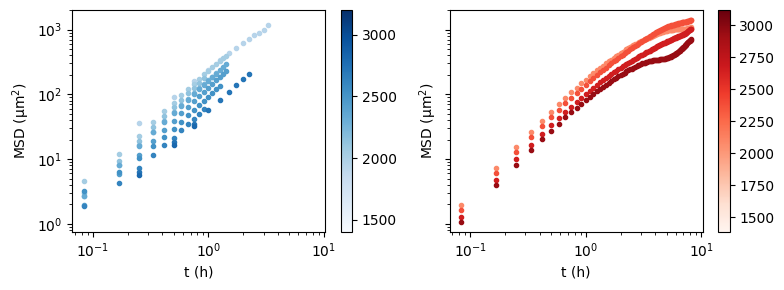

In [12]:
# Create side-by-side log–log MSD plots for experimental (left) and simulation (right) data
fig, ax = plt.subplots(1,2, figsize=(8,3), 
                            sharex=True,
                            sharey=True)

# Plot averaged experimental MSD curves, colored by density bin
for lag_lists, msd_lists, color in zip(lag_exp, msd_exp, cmap_exp):
    lag, msd = average_lists_with_lenghts(lag_lists, msd_lists)
    ax[0].plot(lag, msd, '.', c=color)

# Physical time per frame (in hours) for the simulation MSD
frame_duration_h = 0.0104 * 8

# Plot simulation MSD curves, colored by density bin
for msd, color in zip(msd_sim, cmap_sim):
    lag = np.arange(len(msd)) * frame_duration_h
    ax[1].plot(lag, msd, '.', c=color)

# Use log–log axes and consistent labels for both subplots
for ax_i in ax:
    ax_i.set(xlabel="t (h)",
             ylabel=r"MSD (µm$^2$)",
             xscale="log",
             yscale="log")

# Add colorbars indicating density
norm_exp = mpl.colors.Normalize(vmin=density_bins.min(), vmax=density_bins.max())
norm_sim = mpl.colors.Normalize(vmin=variable_sim.min(), vmax=variable_sim.max())

sm_exp = mpl.cm.ScalarMappable(cmap=mpl.colormaps["Blues"], norm=norm_exp)
sm_sim = mpl.cm.ScalarMappable(cmap=mpl.colormaps["Reds"],  norm=norm_sim)

fig.colorbar(sm_exp, ax=ax[0])
fig.colorbar(sm_sim, ax=ax[1])

fig.tight_layout()

In [ ]:
# Compare diffusion coefficiant of the two.

## Cage diffusion

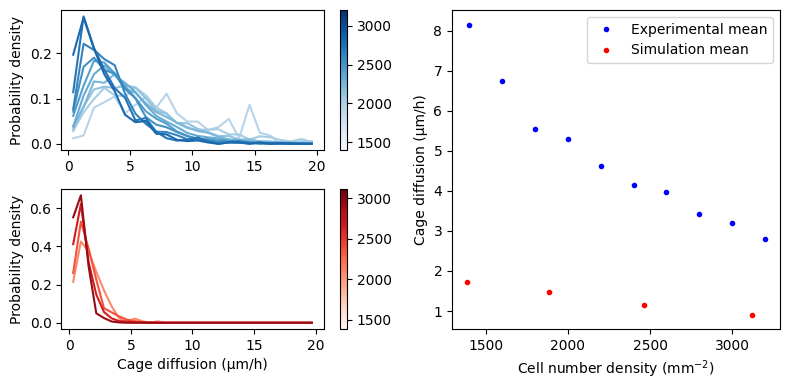

In [35]:
# Create a mosaic layout: experimental and simulation histograms on the left,
# and mean cage diffusion vs density/variable on the right
mosaic_layout = [['exp' , 'width'], 
                 ['sim', 'width']]

fig, ax = plt.subplot_mosaic(mosaic_layout, figsize=(8,4))

n_bins_exp = 24
n_bins_sim = 32
max_cage_distance = 20


# Plot experimental cage diffusion distributions for each density bin
for cage_distances, color in zip(cage_distances_exp, cmap_exp):

    counts, bin_edges = np.histogram(cage_distances, bins=n_bins_exp,
                                                     density=True, 
                                                     range=(0, max_cage_distance))
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax['exp'].plot(bin_centers, counts, c=color)


# Plot simulation cage diffusion distributions for each density
for cage_distances, color in zip(cage_distances_sim, cmap_sim):

    counts, bin_edges = np.histogram(cage_distances, bins=n_bins_sim,
                                                     density=True, 
                                                     range=(0, max_cage_distance))
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax['sim'].plot(bin_centers, counts, c=color)


# Compute mean cage diffusion per bin/dataset for experimental and simulation data
mean_cage_distance_exp = np.array([np.mean(cage_distance) for cage_distance in cage_distances_exp])
mean_cage_distance_sim = np.array([np.mean(cage_distance) for cage_distance in cage_distances_sim])

# Plot mean cage diffusion as a function of cell number density (experiment) and comparison variable (simulation)
valid_exp = mean_cage_distance_exp > 0
valid_sim = mean_cage_distance_sim > 0

ax['width'].plot(density_bins[valid_exp], 
                 mean_cage_distance_exp[valid_exp], 
                 'b.', 
                 label="Experimental mean")
ax['width'].plot(variable_sim[valid_sim], 
                 mean_cage_distance_sim[valid_sim], 
                 'r.', 
                 label="Simulation mean")


ax['exp'].set(ylabel="Probability density")
ax['sim'].set(ylabel="Probability density",
              xlabel="Cage diffusion (µm/h)")

ax['width'].legend()
ax['width'].set(xlabel=r"Cell number density (mm$^{-2}$)", 
                ylabel="Cage diffusion (µm/h)")


# Add colorbars indicating density
norm_exp = mpl.colors.Normalize(vmin=density_bins.min(), vmax=density_bins.max())
norm_sim = mpl.colors.Normalize(vmin=variable_sim.min(), vmax=variable_sim.max())

sm_exp = mpl.cm.ScalarMappable(cmap=mpl.colormaps["Blues"], norm=norm_exp)
sm_sim = mpl.cm.ScalarMappable(cmap=mpl.colormaps["Reds"],  norm=norm_sim)

fig.colorbar(sm_exp, ax=ax['exp'])
fig.colorbar(sm_sim, ax=ax['sim'])

fig.tight_layout()

## Fractional change in neighbours

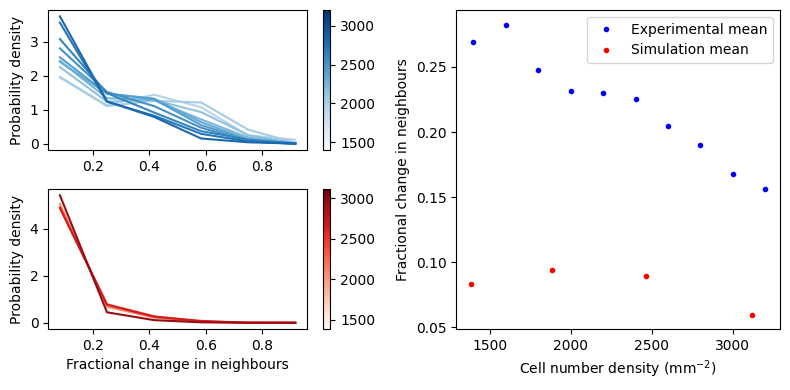

In [ ]:
# Create a mosaic layout: experimental and simulation histograms on the left,
# and mean fractional neighbour change vs density/variable on the right
mosaic_layout = [['exp' , 'width'], 
                 ['sim', 'width']]

fig, ax = plt.subplot_mosaic(mosaic_layout, figsize=(8,4))
n_bins = 6


# Plot experimental distributions of fractional neighbour change for each density bin
for fraction_neighbours, color in zip(fraction_neighbours_exp, cmap_exp):

    counts, bin_edges = np.histogram(fraction_neighbours, bins=n_bins,
                                                          density=True, 
                                                          range=(0, 1))
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax['exp'].plot(bin_centers, counts, c=color)


# Plot simulation distributions of fractional neighbour change for each density
for fraction_neighbours, color in zip(fraction_neighbours_sim, cmap_sim):

    counts, bin_edges = np.histogram(fraction_neighbours, bins=n_bins,
                                                          density=True, 
                                                          range=(0, 1))
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    ax['sim'].plot(bin_centers, counts, c=color)


# Compute mean fractional neighbour change per bin/dataset for experimental and simulation data
mean_fraction_exp = np.array([np.mean(fraction[fraction < 1]) for fraction in fraction_neighbours_exp])
mean_fraction_sim = np.array([np.mean(fraction[fraction < 1]) for fraction in fraction_neighbours_sim])

# Compute mean fractional neighbour change per bin/dataset for experimental and simulation data
valid_exp = mean_cage_distance_exp > 0
valid_sim = mean_cage_distance_sim > 0

ax['width'].plot(density_bins[valid_exp], 
                 mean_fraction_exp[valid_exp], 
                 'b.', 
                 label="Experimental mean")
ax['width'].plot(variable_sim[valid_sim], 
                 mean_fraction_sim[valid_sim], 
                 'r.', 
                 label="Simulation mean")


ax['exp'].set(ylabel="Probability density")
ax['sim'].set(ylabel="Probability density",
              xlabel="Fractional change in neighbours")

ax['width'].legend()
ax['width'].set(xlabel=r"Cell number density (mm$^{-2}$)", 
                ylabel="Fractional change in neighbours")


# Add colorbars indicating density
norm_exp = mpl.colors.Normalize(vmin=density_bins.min(), vmax=density_bins.max())
norm_sim = mpl.colors.Normalize(vmin=variable_sim.min(), vmax=variable_sim.max())

sm_exp = mpl.cm.ScalarMappable(cmap=mpl.colormaps["Blues"], norm=norm_exp)
sm_sim = mpl.cm.ScalarMappable(cmap=mpl.colormaps["Reds"],  norm=norm_sim)

fig.colorbar(sm_exp, ax=ax['exp'])
fig.colorbar(sm_sim, ax=ax['sim'])

fig.tight_layout()